In [61]:
%load_ext autoreload
%autoreload 2
from ucimlrepo import fetch_ucirepo 
from utils import get_binary_bool
import pandas as pd 
import warnings
warnings.filterwarnings("ignore", message="X has feature names")
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in")
warnings.filterwarnings("ignore", category=UserWarning)

def get_uci_df(uci_id: int):
    """
    Fetch a UCI dataset via ucimlrepo
    """
    ds = fetch_ucirepo(id=uci_id)

    X = ds.data.features.copy()
    y = ds.data.targets.copy() 
    return pd.concat([X, y], axis=1), ds



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Real example usage 
This notebook is meant to demonstrate how to use our method in real world settings when
Q is unobserved. 

For our biased distribution, we use the CDC Diabetes Health Indicators Dataset 
on UCI data repository and learn a logistic regression model to predict stroke. 
See the data here: https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators


For the target distribution Q we use the 2013 NHANES dataset, which has limited sample overlap on a few variables.  https://wwwn.cdc.gov/nchs/nhanes/search/DataPage.aspx?Component=Questionnaire&CycleBeginYear=2013


Note: this is not meant to be an evaluation of a realistic case of selection bias, but rather just to demonstrate how users can interact with our method and implementation. 

### Load and match datasets 

In [2]:
# Biased distribution P = CDC Diabetes Health Indicators Dataset
P_df, meta = get_uci_df(891)
P_df['BMIOver30'] = (P_df['BMI'] > 30).astype(int)
P_df['AgeOver65'] = (P_df['Age'] >= 10).astype(int) # Age is coded 1-13
P_binary = P_df[P_df.columns[get_binary_bool(P_df.to_numpy())]]
P_binary.mean()



HighBP                  0.429001
HighChol                0.424121
CholCheck               0.962670
Smoker                  0.443169
Stroke                  0.040571
HeartDiseaseorAttack    0.094186
PhysActivity            0.756544
Fruits                  0.634256
Veggies                 0.811420
HvyAlcoholConsump       0.056197
AnyHealthcare           0.951053
NoDocbcCost             0.084177
DiffWalk                0.168224
Sex                     0.440342
Diabetes_binary         0.139333
BMIOver30               0.288860
AgeOver65               0.351112
dtype: float64

In [4]:
# Target distribution Q: NHANES 2013-2014
Q_df, meta = get_uci_df(887)
Q_df['Sex'] = (Q_df['RIAGENDR'] == 1).astype(int) # Align variables between datasets
Q_df['BMIOver30'] = (Q_df['BMXBMI'] > 30).astype(int)
Q_df['Diabetes_binary'] = ((Q_df['DIQ010'] == 1) | (Q_df['DIQ010'] == 3)).astype(int)



In [5]:
# Pick variables for our prediction task 
Xtilde_cols = ['Smoker', 'Diabetes_binary', 'Sex']
Y_col = 'Stroke'

# Suppose we think that these are two potential drivers of selection 
# Importantly, the joint is fully observed in Q and P
Utilde_cols = ['Diabetes_binary', 'Sex'] 
QUtilde_df = Q_df[Utilde_cols]

In [29]:
# We picked these target first moments based on the raw table counts from the NHANES 2013 dataset: 
# https://wwwn.cdc.gov/nchs/nhanes/search/DataPage.aspx?Component=Questionnaire&CycleBeginYear=2013
Q_mu = {
    'HighBP': 2174/6464,
 'HighChol': 2100/6464,
 'CholCheck': 2583/6464,
 'Smoker': 2579/7168,
 'Stroke': 202/9770,
 'HeartDiseaseorAttack': 230/9770,
 'PhysActivity': 2186/9484,
 'HvyAlcoholConsump': 736/5924,
 'AnyHealthcare': 8594/10175,
 'DiffWalk': 241/3815,
 'Sex': 0.488586,
 'Diabetes_binary': 0.034680,
 'BMIOver30': 0.310360,
 'AgeOver65': 364/(1914+364)}
Q_mu = pd.DataFrame(Q_mu,index=[0])
Q_var = Q_mu*(1-Q_mu) #Var for binary p is p * (1-p) where p is the E[X]
Q_mu


,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,DiffWalk,Sex,Diabetes_binary,BMIOver30,AgeOver65
0,0.336324,0.324876,0.399598,0.359794,0.020676,0.023541,0.230493,0.12424,0.844619,0.063172,0.488586,0.03468,0.31036,0.159789


### Run our method 
Users should first define the MethodConfig that parameterizes the estimation method. 
Then the can call 
```
gapest = Generalization_Bound_Estimator(simulate_mode=False, method_config=method_config)
gapest.run( ....)
```
Please refer to Generalization_Bound_Estimator.run for more details. 

In [77]:
from gap_est_utils import Generalization_Bound_Estimator, MethodConfig
method_config = MethodConfig(
    heuristic_bootstrap=700,
    heuristic_alpha=0.0001,
    heuristic_type='exact', # fast | exact
    clf='lr', # logistic regression classifier for fP
    standardize_P=False 
)

In [44]:


gapest = Generalization_Bound_Estimator(simulate_mode=False, method_config=method_config)
results = []
for seed in range(5): 
    results.append(gapest.run(Xtilde_cols=Xtilde_cols, Y_col=Y_col, Utilde_cols=Utilde_cols, seed=seed, 
                                pred_model=method_config.get_model(seed=seed), 
                                baselines = ['calib','eb'], # Optionally, run baselines to compare
                                Q_df=QUtilde_df, Q_mu=Q_mu, P_df=P_binary[Q_mu.columns],
                                Q_var=Q_var,
                                run_diagnostics=True))
resullts = pd.concat(results)

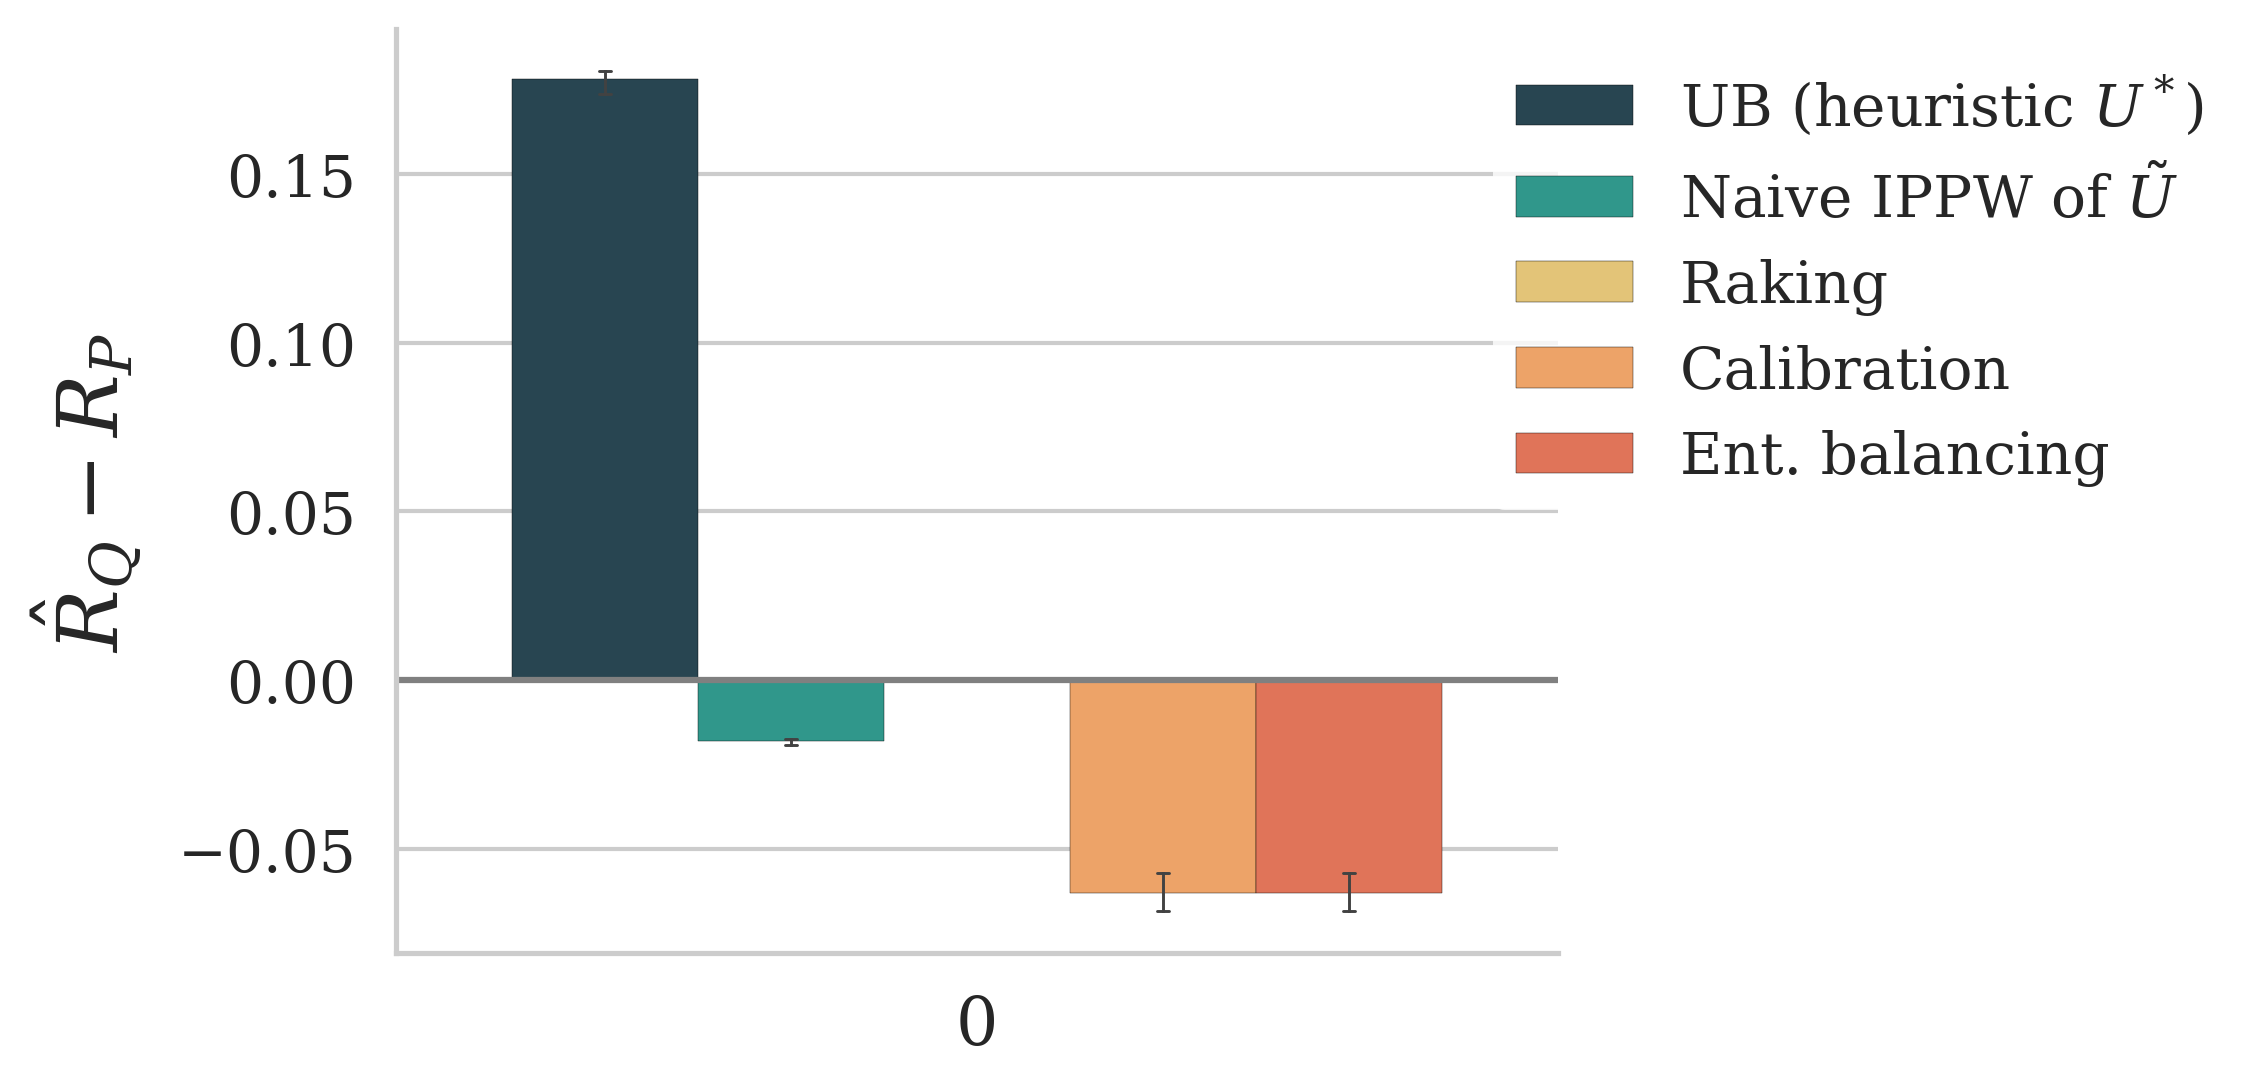

In [62]:
# 1. Plot all method's predicted generalization gap 
plot_gen_gap(results,methods=[
            'baseline_calib_logloss_vs_RP',
            'baseline_eb_logloss_vs_RP',
            'ippw_Utilde_logloss_vs_RP',
            'ub_predUstar_logloss_vs_RP'
            ])

The results show that our method indicates there is a significant gap of about 0.15 in logloss 
when applied to the target distribution Q. 
The baselines seem to state that the model fP will perform better on Q than P. 

In [56]:
# 2. Investigate assumption violation diagnostics

results[['Utilde_propensity_ks_stat', 'Utilde_propensity_ks_pval',
       'heuristic_w_de', 'propinv_ci_avg_var']].rename(columns={'Utilde_propensity_ks_stat': "KS Propsensity (stat)", 'Utilde_propensity_ks_pval': "KS Propensity (pval)", 
 "heuristic_w_de": "Weight design effect", "propinv_ci_avg_var": "Prop. Inv. Var."}).iloc[:1]

,KS Propsensity (stat),KS Propensity (pval),Weight design effect,Prop. Inv. Var.
0,0.104653,5.490441e-22,125.100654,0.000405


Weight design effect is very high, which could indicate lack of common support between the two distributions. It is possible more data from P needs to be collected. 